In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [3]:
def read_parquet_file(file_name):
    df = pd.read_parquet(file_name, engine="fastparquet")
    print(file_name)
    print(df.head())
    print('########################################################################')
    print('info')
    print(df.info())
    return df

### Read the sales data and show info and descriptive statistics:

In [30]:
sales = read_parquet_file('20260218_144523_sales_data.parquet')

20260218_144523_sales_data.parquet
        date         category_name  item_id  sold_quantity  price  store_id
0 2025-04-01     Angebot Brötchen       139           15.0    0.0         0
1 2025-04-01  Angebot Feinbäckerei      138           28.0    0.0         0
2 2025-04-01  Angebot Heißgetränke      106           25.0    0.0         0
3 2025-04-01  Angebot Heißgetränke      539            5.0    1.4         0
4 2025-04-01         Angebot Snack      176            1.0    0.0         0
########################################################################
info
<class 'pandas.DataFrame'>
RangeIndex: 713637 entries, 0 to 713636
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           713637 non-null  datetime64[ns]
 1   category_name  713637 non-null  object        
 2   item_id        713637 non-null  int64         
 3   sold_quantity  713637 non-null  float64       
 4   price          

#### Observation
- the max. price is very high
- the max. quantity is also very high
- missing values in price
- negative quantities
- there is only one line for Brotwaage and Angebot Gastro

In [209]:
sales.describe()

,date,item_id,sold_quantity,price,store_id
count,713637,713637.000000,713637.000000,696648.000000,713637.000000
mean,2025-05-15 16:04:01.050282240,262.957623,15.845915,2.747405,30.802189
min,2025-04-01 00:00:00,0.000000,-1.000000,-22.000000,0.000000
25%,2025-04-24 00:00:00,67.000000,1.000000,1.100000,14.000000
50%,2025-05-16 00:00:00,220.000000,4.000000,2.600000,30.000000
75%,2025-06-07 00:00:00,449.000000,12.000000,3.800000,46.000000
max,2025-06-30 00:00:00,676.000000,2425.000000,115.000000,83.000000
std,NaN,216.843557,60.843418,2.129056,19.148652


In [210]:
sales['category_name'].value_counts()

category_name
Brötchen                195190
Brot                    150172
Snack                    75142
Kaltgetränke 19%         61263
Kuchen                   61095
Heißgetränke             48316
Feinbäckerei             46475
Snack Belag              22334
Konditorei               14304
Angebot Brötchen         11529
Angebot Feinbäckerei      6179
Kaltgetränke 7%           5845
Printen/Kekse             5078
Angebot Heißgetränke      4623
Eigerichte                3241
Angebot Brot               974
Gastro Gerichte            929
Angebot Snack              670
Frühstücke                 113
Printen Waage               98
Angebot Kuchen              65
Brotwaage                    1
Angebot Gastro               1
Name: count, dtype: int64

In [ ]:
sales_adj = sales[(sales['category_name'] != 'Brotwaage') & (sales['category_name'] != 'Angebot Gastro')]

#### check the distribution of price
- the higher prices seems to be for birthday cakes

<Axes: ylabel='price'>

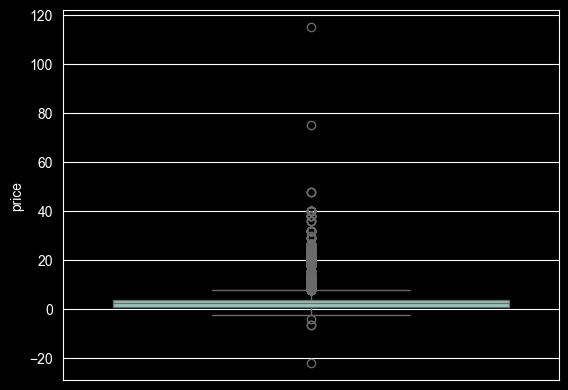

In [67]:
sns.boxplot(sales['price'])

In [70]:
sales[sales['price'] > 60 ]

,date,category_name,item_id,sold_quantity,price,store_id
195097,2025-04-26,Konditorei,417,1.0,115.0,5
246721,2025-05-03,Konditorei,416,1.0,75.0,5


#### check the distribution of sold quantity
- the volatility of sold quantities is very high

<Axes: ylabel='sold_quantity'>

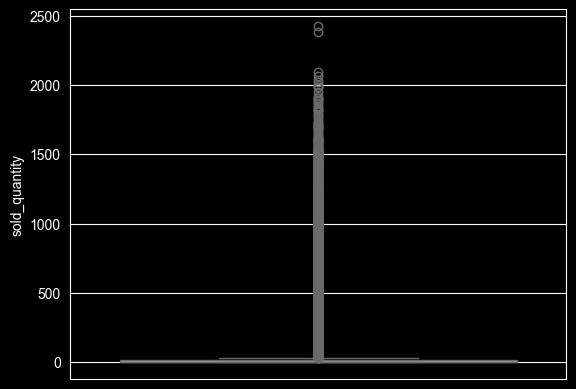

In [72]:
sns.boxplot(sales['sold_quantity'])



#### Investigate the missing 'price'




         date category_name  item_id  sold_quantity  price  store_id
28 2025-04-01          Brot      315            0.0    NaN         0
39 2025-04-01          Brot      338            0.0    NaN         0
41 2025-04-01          Brot      340            0.0    NaN         0
43 2025-04-01          Brot      342            0.0    NaN         0
77 2025-04-01      Brötchen       52            0.0    NaN         0
###################################################################
                                date       item_id  sold_quantity  price  \
count                          16989  16989.000000        16989.0    0.0   
mean   2025-05-15 17:22:58.845135104    246.083996            0.0    NaN   
min              2025-04-01 00:00:00     51.000000            0.0    NaN   
25%              2025-04-24 00:00:00    248.000000            0.0    NaN   
50%              2025-05-16 00:00:00    256.000000            0.0    NaN   
75%              2025-06-07 00:00:00    340.000000            

Text(0.5, 1.0, 'distribution of missing price by product category')

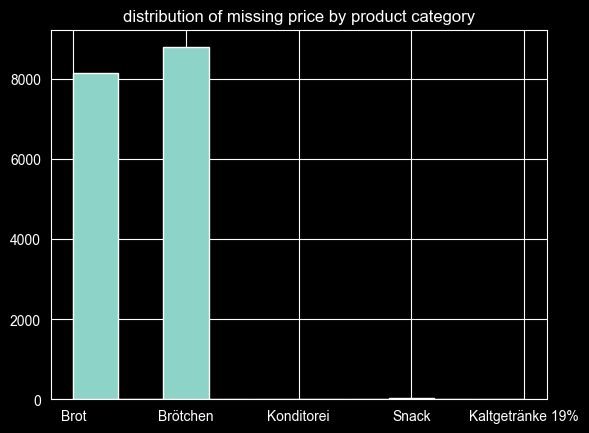

In [6]:
missing_price = sales[sales['price'].isna()]
print(missing_price.head())
print('###################################################################')
print(missing_price.describe())
print('###################################################################')
print('Number of missing price: ', len(missing_price))
print('###################################################################')
#print(missing_price['store_id'].value_counts())
plt.hist(missing_price['category_name'])
plt.title('distribution of missing price by product category')

#### - Sold quantity is always 0 when price is missing -> We could delete these lines
- delete the missing prices

In [7]:
sales.isna().any()

date             False
category_name    False
item_id          False
sold_quantity    False
price             True
store_id         False
dtype: bool

In [33]:
sales_adj = sales.dropna(axis = 0)

#### - Missing prices are removed

In [9]:
sales.isna().any()

date             False
category_name    False
item_id          False
sold_quantity    False
price            False
store_id         False
dtype: bool

#### Investigate negative sold quantities

In [34]:
#sns.boxplot(x = 'category_name', y = 'sold_quantity', data = sales[sales['category_name'].isin(['Brot'])])
negative_quantity = sales_adj[sales_adj['sold_quantity'] < 0]
print(negative_quantity.head())
len(negative_quantity)

             date category_name  item_id  sold_quantity  price  store_id
661830 2025-06-24      Brötchen       13           -1.0   4.71        35
661839 2025-06-24      Brötchen       34           -1.0   6.50        35


2

#### - It seems to be exceptional cases.
- suggest to remove the 2 lines

In [35]:
sales_adj = sales_adj[sales_adj['sold_quantity'] >= 0]

#### Other Observation 1:
- one item_id might refer to different products with differnt prices, even within the same store
#### Suggestion:
- clarify the item ID

In [57]:
for item in sales['item_id'].unique():
    prices = sales[sales['item_id'] == item]['price'].unique()
    category = sales[sales['item_id'] == item]['category_name'].unique()
    print(item, len(prices), category)

#plt.scatter(sales[sales['item_id'] == 248]['date'], sales[sales['item_id'] == 248]['price'])

139 1 ['Angebot Brötchen ']
138 1 ['Angebot Feinbäckerei']
106 1 ['Angebot Heißgetränke']
539 1 ['Angebot Heißgetränke']
176 1 ['Angebot Snack']
474 2 ['Angebot Snack']
484 1 ['Angebot Snack']
59 138 ['Brot' 'Brötchen']
67 162 ['Brot']
68 180 ['Brot']
70 5 ['Brot']
71 81 ['Brot']
74 91 ['Brot']
75 115 ['Brot' 'Brötchen']
79 89 ['Brot']
84 153 ['Brot' 'Brötchen']
86 132 ['Brot']
88 154 ['Brot']
93 141 ['Brot']
94 102 ['Brot']
96 114 ['Brot']
107 104 ['Brot']
109 76 ['Brot']
308 42 ['Brot']
309 22 ['Brot']
312 77 ['Brot' 'Gastro Gerichte']
313 20 ['Brot']
314 61 ['Brot' 'Gastro Gerichte']
315 1 ['Brot']
316 23 ['Brot']
317 54 ['Brot']
319 21 ['Brot']
321 15 ['Brot']
322 49 ['Brot']
326 4 ['Brot']
328 49 ['Brot']
335 17 ['Brot']
336 68 ['Brot']
337 24 ['Brot']
338 1 ['Brot']
339 34 ['Brot']
340 2 ['Brot']
341 43 ['Brot']
342 1 ['Brot']
343 29 ['Brot']
344 65 ['Brot']
375 9 ['Brot']
0 20 ['Brötchen']
1 3 ['Brötchen']
2 40 ['Brötchen']
5 1 ['Brötchen']
6 3 ['Brötchen']
7 1 ['Brötchen']
8 2 

In [217]:
sales_adj[(sales_adj['item_id'] == 59) ]
#sales_adj[(sales_adj['item_id'] == 248) ]

,date,category_name,item_id,sold_quantity,price,store_id,month,weekday
7,2025-04-01,Brot,59,6.0,2.80,0,4,2
82,2025-04-01,Brötchen,59,0.0,1.65,0,4,2
210,2025-04-01,Brot,59,3.5,2.80,1,4,2
556,2025-04-01,Brötchen,59,7.0,1.40,3,4,2
601,2025-04-01,Brot,59,2.0,2.80,4,4,2
...,...,...,...,...,...,...,...,...
712637,2025-06-30,Brot,59,5.0,2.90,55,6,1
712776,2025-06-30,Brot,59,3.0,2.32,56,6,1
712868,2025-06-30,Brot,59,4.0,2.90,57,6,1
712988,2025-06-30,Brot,59,11.0,2.90,58,6,1


#### Other Observation 2
- number of lines for each store every day is different

In [60]:
for day in sales['date'].unique():
    n_entries = len(sales[(sales['store_id'] == 1) & (sales['date'] == day)])
    print(day, ': ', n_entries)

2025-04-01 00:00:00 :  209
2025-04-02 00:00:00 :  190
2025-04-03 00:00:00 :  192
2025-04-04 00:00:00 :  198
2025-04-05 00:00:00 :  176
2025-04-06 00:00:00 :  78
2025-04-07 00:00:00 :  179
2025-04-08 00:00:00 :  182
2025-04-09 00:00:00 :  161
2025-04-10 00:00:00 :  167
2025-04-11 00:00:00 :  195
2025-04-12 00:00:00 :  180
2025-04-13 00:00:00 :  75
2025-04-14 00:00:00 :  187
2025-04-15 00:00:00 :  190
2025-04-16 00:00:00 :  179
2025-04-17 00:00:00 :  174
2025-04-18 00:00:00 :  0
2025-04-19 00:00:00 :  156
2025-04-20 00:00:00 :  57
2025-04-21 00:00:00 :  0
2025-04-22 00:00:00 :  189
2025-04-23 00:00:00 :  174
2025-04-24 00:00:00 :  172
2025-04-25 00:00:00 :  184
2025-04-26 00:00:00 :  172
2025-04-27 00:00:00 :  84
2025-04-28 00:00:00 :  186
2025-04-29 00:00:00 :  211
2025-04-30 00:00:00 :  187
2025-05-01 00:00:00 :  13
2025-05-02 00:00:00 :  187
2025-05-03 00:00:00 :  175
2025-05-04 00:00:00 :  87
2025-05-05 00:00:00 :  185
2025-05-06 00:00:00 :  197
2025-05-07 00:00:00 :  191
2025-05-08 

#### Processing data
- adding the weekday and month info to the sales_adj dataframe

In [62]:
sales_adj['month'] = sales_adj['date'].dt.month
sales_adj['weekday'] = sales_adj['date'].dt.weekday
sales_adj['weekday'] = sales_adj['weekday'] + 1
sales_adj.head()

,date,category_name,item_id,sold_quantity,price,store_id,month,weekday
0,2025-04-01,Angebot Brötchen,139,15.0,0.0,0,4,2
1,2025-04-01,Angebot Feinbäckerei,138,28.0,0.0,0,4,2
2,2025-04-01,Angebot Heißgetränke,106,25.0,0.0,0,4,2
3,2025-04-01,Angebot Heißgetränke,539,5.0,1.4,0,4,2
4,2025-04-01,Angebot Snack,176,1.0,0.0,0,4,2


#### Read Holidays data
- subdivision_code is always DE-NW
- there is no missing value
- there are duplicates, e.g. 2025-04-13 exits multiple times as both school holiday and special day, and it is a holiday in every area

In [75]:
holidays = read_parquet_file('20260218_144523_holidays.parquet')

20260218_144523_holidays.parquet
  zipcode subdivision_code       date holiday_name    holiday_type
0   41812            DE-NW 2025-04-01   Zuckerfest     special_day
1   41812            DE-NW 2025-04-02   Zuckerfest     special_day
2   41812            DE-NW 2025-04-12  Osterferien  school_holiday
3   41812            DE-NW 2025-04-13  Osterferien  school_holiday
4   41812            DE-NW 2025-04-13  Palmsonntag     special_day
########################################################################
info
<class 'pandas.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   zipcode           1301 non-null   object        
 1   subdivision_code  1301 non-null   object        
 2   date              1301 non-null   datetime64[ns]
 3   holiday_name      1301 non-null   object        
 4   holiday_type      1301 non-null   object        
dtypes: dateti

In [77]:
holidays.isna().any()

zipcode             False
subdivision_code    False
date                False
holiday_name        False
holiday_type        False
dtype: bool

In [79]:
holidays[holidays['date'] == '2025-04-13']

,zipcode,subdivision_code,date,holiday_name,holiday_type
3,41812,DE-NW,2025-04-13,Osterferien,school_holiday
4,41812,DE-NW,2025-04-13,Palmsonntag,special_day
38,41836,DE-NW,2025-04-13,Osterferien,school_holiday
39,41836,DE-NW,2025-04-13,Palmsonntag,special_day
73,41849,DE-NW,2025-04-13,Osterferien,school_holiday
...,...,...,...,...,...
1197,52531,DE-NW,2025-04-13,Osterferien,school_holiday
1198,52531,DE-BB,2025-04-13,Palmsonntag,special_day
1199,52531,DE-NW,2025-04-13,Palmsonntag,special_day
1269,52538,DE-NW,2025-04-13,Osterferien,school_holiday


In [93]:
print(holidays['holiday_type'].unique())


['special_day' 'school_holiday' 'holiday']


In [100]:
special_days = holidays[holidays['holiday_type'] == 'special_day']
special_days_index = special_days['zipcode'].astype('str') + special_days['date'].astype('str')
print(special_days_index)
special_days.drop('holiday_name', axis = 1).duplicated().sum()


0       418122025-04-01
1       418122025-04-02
4       418122025-04-13
8       418122025-04-17
12      418122025-04-19
             ...       
1292    525382025-05-11
1294    525382025-05-30
1295    525382025-06-01
1299    525382025-06-20
1300    525382025-06-24
Length: 443, dtype: str


np.int64(0)

In [101]:
school_holidays = holidays[holidays['holiday_type'] == 'school_holiday']
school_holidays_index = school_holidays['zipcode'].astype('str') + school_holidays['date'].astype('str')
school_holidays.drop('holiday_name', axis = 1).duplicated().sum()

np.int64(0)

In [102]:
std_holidays = holidays[holidays['holiday_type'] == 'holiday']
std_holidays_index = std_holidays['zipcode'].astype('str') + std_holidays['date'].astype('str')
std_holidays.drop('holiday_name', axis = 1).duplicated().sum()

np.int64(0)

#### Read the stores data
- subdivision_code and country_code do not add further information
- there is no duplicates

In [85]:
stores = read_parquet_file('20260218_144523_stores.parquet')

20260218_144523_stores.parquet
  subdivision_code country_code zipcode  average_weekly_revenue_Q1  store_id
0            DE-NW           DE   52062               21448.248159         0
1            DE-NW           DE   52224               17844.961211         1
2            DE-NW           DE   52134               12808.989643         2
3            DE-NW           DE   52062                7635.616974         3
4            DE-NW           DE   52222               21000.922881         4
########################################################################
info
<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subdivision_code           84 non-null     object 
 1   country_code               84 non-null     object 
 2   zipcode                    84 non-null     object 
 3   average_weekly_revenue_Q1  84 non-null     float64
 4

In [87]:
stores['store_id'].duplicated().sum()

np.int64(0)

#### read weather data
- chanceofXXX are always zeros

In [90]:
weather = read_parquet_file('20260218_144523_weather.parquet')

20260218_144523_weather.parquet
        date   time zipcode  temperature  wind_speed  wind_degree wind_dir  \
0 2025-04-01  20:00   41812         10.0        16.0         79.0      ENE   
1 2025-04-01  21:00   41812          9.0        16.0         75.0      ENE   
2 2025-04-01  22:00   41812          9.0        18.0         71.0      ENE   
3 2025-04-01  23:00   41812          8.0        20.0         70.0      ENE   
4 2025-04-01  00:00   41812          6.0        10.0         52.0       NE   

   weather_code weather_description  precip  ...  chanceofremdry  \
0           113               Clear     0.0  ...             0.0   
1           113               Clear     0.0  ...             0.0   
2           113               Clear     0.0  ...             0.0   
3           113               Clear     0.0  ...             0.0   
4           113               Clear     0.0  ...             0.0   

   chanceofwindy  chanceofovercast  chanceofsunshine  chanceoffrost  \
0            0.0   

In [91]:
weather.describe()

,date,temperature,wind_speed,wind_degree,weather_code,precip,humidity,visibility,pressure,cloudcover,...,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
count,78624,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,...,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.000000
mean,2025-05-16 00:00:00,13.819521,13.142577,177.389474,141.274267,0.059655,69.556853,9.577101,1018.022563,39.178139,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.633916
min,2025-04-01 00:00:00,-2.000000,0.000000,0.000000,113.000000,0.000000,23.000000,0.000000,998.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
25%,2025-04-23 00:00:00,10.000000,9.000000,87.000000,113.000000,0.000000,57.000000,10.000000,1015.000000,7.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
50%,2025-05-16 00:00:00,13.000000,12.000000,204.000000,116.000000,0.000000,71.000000,10.000000,1018.000000,26.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
75%,2025-06-08 00:00:00,17.000000,17.000000,257.000000,143.000000,0.000000,84.000000,10.000000,1022.000000,74.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.000000
max,2025-06-30 00:00:00,32.000000,39.000000,360.000000,389.000000,8.500000,99.000000,10.000000,1029.000000,100.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.000000
std,NaN,5.665801,6.522310,101.179081,57.894296,0.288629,16.739121,1.750297,5.612091,35.601236,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.890117


In [108]:
weather_adj = weather[['date', 'time', 'zipcode', 'temperature', 'wind_speed', 'wind_degree',
       'wind_dir', 'weather_code', 'weather_description', 'precip', 'humidity',
       'visibility', 'pressure', 'cloudcover', 'heatindex', 'dewpoint',
       'windchill', 'windgust', 'feelslike', 'uv_index']]

In [180]:
weather_adj_agg = weather_adj.drop(['time', 'wind_dir','weather_description'], axis = 1).groupby(['date', 'zipcode']).mean()
weather_adj_agg = weather_adj_agg.reset_index()
weather_adj_agg.head()

,date,zipcode,temperature,wind_speed,wind_degree,weather_code,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,uv_index
0,2025-04-01,41812,8.750000,16.541667,72.333333,113.375,0.0,60.125000,10.0,1025.958333,6.125000,8.750000,0.916667,6.208333,25.750000,6.208333,2.208333
1,2025-04-01,41836,8.750000,16.541667,72.333333,113.375,0.0,60.125000,10.0,1025.958333,6.125000,8.750000,0.916667,6.208333,25.750000,6.208333,2.208333
2,2025-04-01,41849,8.416667,16.833333,72.083333,113.250,0.0,60.750000,10.0,1025.875000,5.666667,8.416667,0.708333,6.000000,26.708333,6.000000,2.208333
3,2025-04-01,52062,7.541667,16.500000,78.625000,113.250,0.0,64.458333,10.0,1025.750000,5.833333,7.541667,0.750000,4.875000,25.958333,4.875000,2.166667
4,2025-04-01,52064,7.541667,16.500000,78.625000,113.250,0.0,64.458333,10.0,1025.750000,5.833333,7.541667,0.750000,4.875000,25.958333,4.875000,2.166667


#### merge the datasets

In [181]:
df = pd.merge(sales_adj, stores[['zipcode', 'average_weekly_revenue_Q1', 'store_id']],
              left_on='store_id', right_on='store_id', how='left')
df = pd.merge(df, weather_adj_agg, left_on=['date', 'zipcode'], right_on= ['date', 'zipcode'], how = 'left')
df.head()

,date,category_name,item_id,sold_quantity,price,store_id,month,weekday,zipcode,average_weekly_revenue_Q1,...,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,uv_index
0,2025-04-01,Angebot Brötchen,139,15.0,0.0,0,4,2,52062,21448.248159,...,64.458333,10.0,1025.75,5.833333,7.541667,0.75,4.875,25.958333,4.875,2.166667
1,2025-04-01,Angebot Feinbäckerei,138,28.0,0.0,0,4,2,52062,21448.248159,...,64.458333,10.0,1025.75,5.833333,7.541667,0.75,4.875,25.958333,4.875,2.166667
2,2025-04-01,Angebot Heißgetränke,106,25.0,0.0,0,4,2,52062,21448.248159,...,64.458333,10.0,1025.75,5.833333,7.541667,0.75,4.875,25.958333,4.875,2.166667
3,2025-04-01,Angebot Heißgetränke,539,5.0,1.4,0,4,2,52062,21448.248159,...,64.458333,10.0,1025.75,5.833333,7.541667,0.75,4.875,25.958333,4.875,2.166667
4,2025-04-01,Angebot Snack,176,1.0,0.0,0,4,2,52062,21448.248159,...,64.458333,10.0,1025.75,5.833333,7.541667,0.75,4.875,25.958333,4.875,2.166667


### check the relationship between sold quantity and other variables

<Axes: >

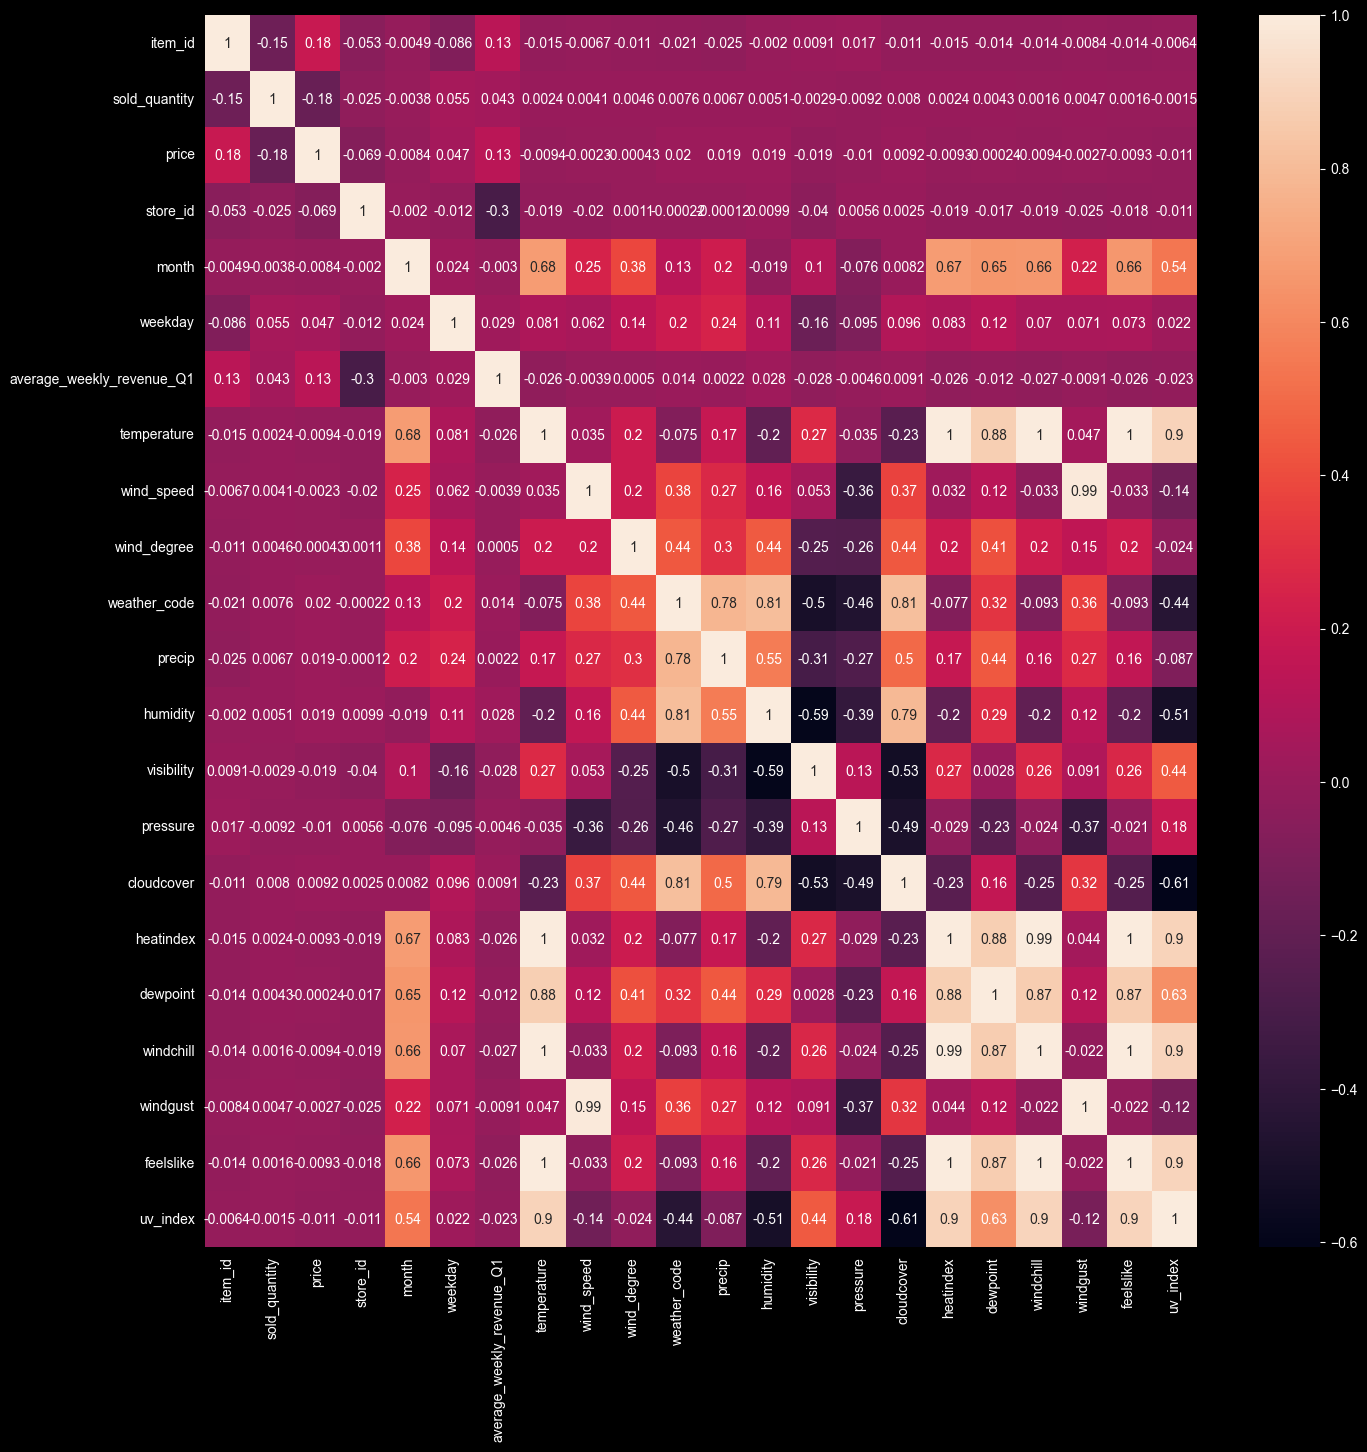

In [185]:
plt.figure(figsize=(16,16))
sns.heatmap(df.select_dtypes(['int', 'float']).corr(), annot=True)

#### Merge the dataframe with holiday data

In [ ]:
df['date_zipcode'] = df['zipcode'].astype('str') + df['date'].astype('str')
df['special_day'] = df['date_zipcode'].isin(special_days_index).astype('int')
df['school_holiday'] = df['date_zipcode'].isin(school_holidays_index).astype('int')
df['std_holiday'] = df['date_zipcode'].isin(std_holidays_index).astype('int')
df.head()

In [193]:
sales_agg1 = df[['category_name', 'sold_quantity']].groupby(['category_name']).sum()
sales_agg1 = sales_agg1.reset_index().sort_values('sold_quantity', ascending = False)
sales_agg1.head(11)

,category_name,sold_quantity
7,Brötchen,8188491.760
6,Brot,774266.593
19,Snack,661963.140
9,Feinbäckerei,457819.100
12,Heißgetränke,417970.420
16,Kuchen,204264.066
1,Angebot Brötchen,199367.500
13,Kaltgetränke 19%,124618.000
15,Konditorei,70989.350
20,Snack Belag,64063.450


In [194]:
top10_categories = sales_agg1['category_name'].iloc[0:10]
top10_categories_wo = sales_agg1['category_name'].iloc[1:10]
other_categories = sales_agg1['category_name'].iloc[10:]


Text(0.5, 1.0, 'Top 10 categories by weekday (wo Brötchen)')

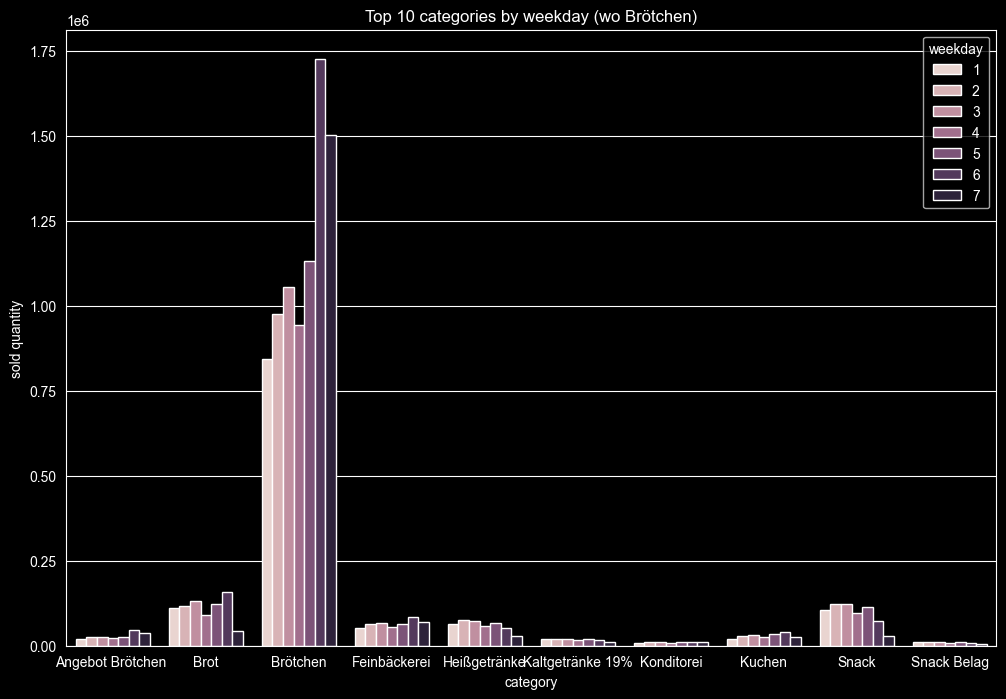

In [123]:
sales_agg2 = df[['category_name', 'weekday', 'sold_quantity']].groupby(['category_name', 'weekday' ]).sum()
sales_agg2 = sales_agg2.reset_index()
sales_agg2_top = sales_agg2[sales_agg2['category_name'].isin(top10_categories)]
plt.figure(figsize = (12,8))
sns.barplot(x = 'category_name', y = 'sold_quantity', hue = 'weekday', data = sales_agg2_top)
plt.xlabel('category')
plt.ylabel('sold quantity')
plt.title('Top 10 categories by weekday (wo Brötchen)')

Text(0.5, 1.0, 'Top 10 categories by weekday (wo Brötchen)')

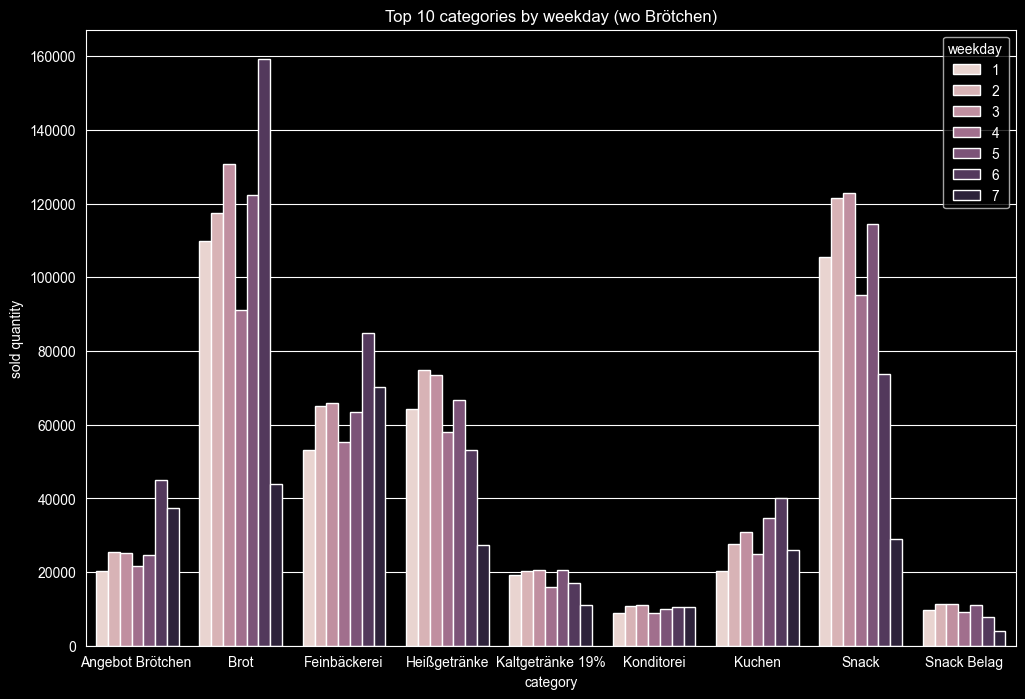

In [124]:
sales_agg2 = df[['category_name', 'weekday', 'sold_quantity']].groupby(['category_name', 'weekday' ]).sum()
sales_agg2 = sales_agg2.reset_index()
sales_agg2_top = sales_agg2[sales_agg2['category_name'].isin(top10_categories_wo)]
plt.figure(figsize = (12,8))
sns.barplot(x = 'category_name', y = 'sold_quantity', hue = 'weekday', data = sales_agg2_top)
plt.xlabel('category')
plt.ylabel('sold quantity')
plt.title('Top 10 categories by weekday (wo Brötchen)')

Text(0.5, 1.0, 'other categories by weekday')

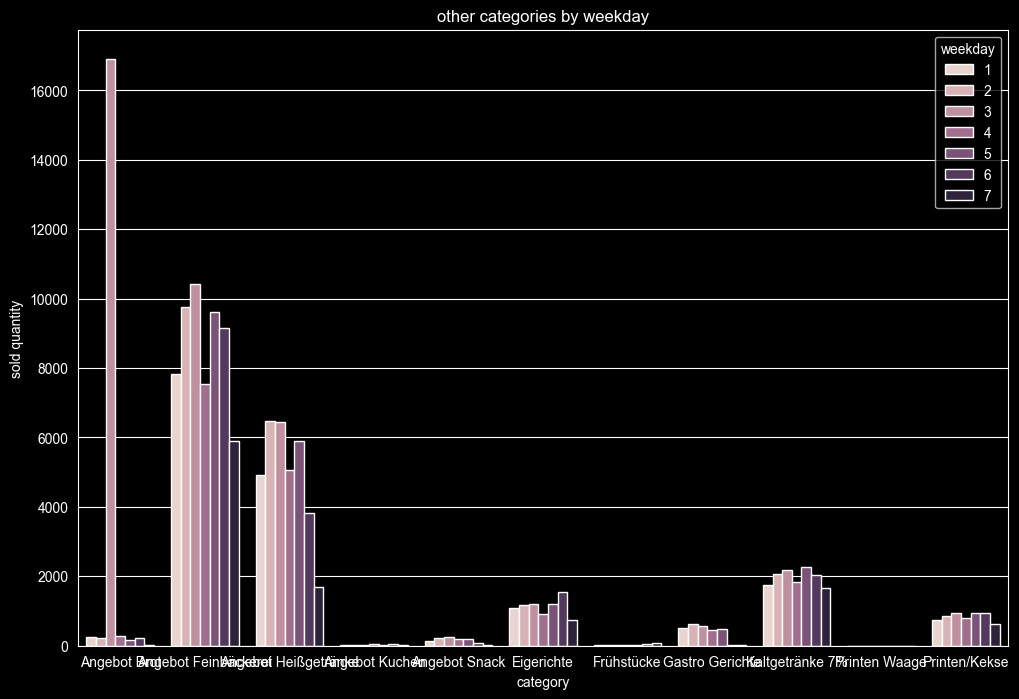

In [119]:
sales_agg2_other = sales_agg2[sales_agg2['category_name'].isin(other_categories)]
plt.figure(figsize = (12,8))
sns.barplot(x = 'category_name', y = 'sold_quantity', hue = 'weekday', data = sales_agg2_other)
plt.xlabel('category')
plt.ylabel('sold quantity')
plt.title('other categories by weekday')

#### There is a huge peak on Wednesday for Angebot Brot. Price of Brot is 0

In [152]:
df[(df['category_name']=='Angebot Brot')][['weekday','price', 'sold_quantity']].groupby(['weekday','price']).sum().sort_values('sold_quantity', ascending = False)

,,sold_quantity
weekday,price,
3,0.00,16723.0
1,0.15,185.0
4,0.15,162.0
2,0.15,131.0
3,0.15,103.0
6,0.15,83.0
5,0.15,66.0
4,3.20,64.0
6,3.20,56.0


#### There are many prices = 0

In [159]:
print(len(df[df['price'] == 0]))
print(len(df[df['price'] == 0])/len(df))
df[df['price'] == 0][['category_name', 'sold_quantity']].groupby('category_name').sum().sort_values('sold_quantity', ascending = False)

48260
0.06927498119556043


,sold_quantity
category_name,
Brötchen,198366.00
Angebot Brötchen,145612.50
Angebot Feinbäckerei,57398.00
Feinbäckerei,47110.00
Angebot Heißgetränke,33654.25
Brot,31825.84
Angebot Brot,16723.00
Angebot Snack,803.00
Heißgetränke,709.00


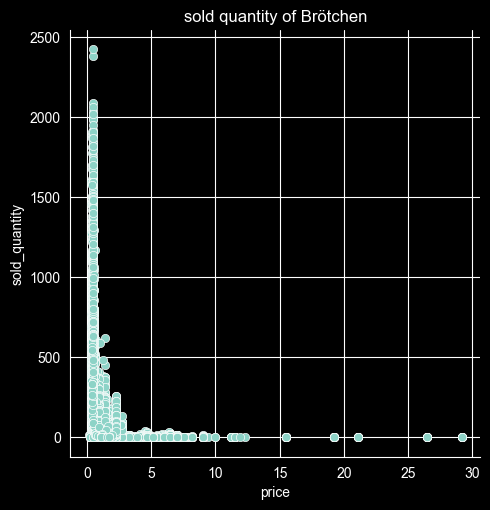

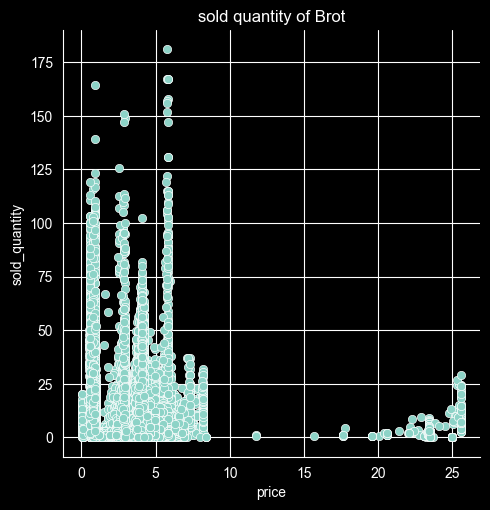

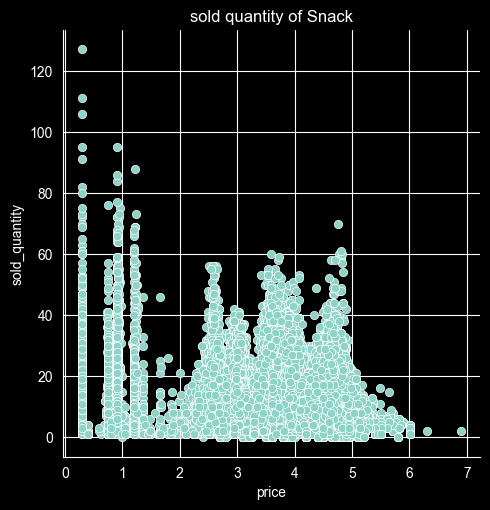

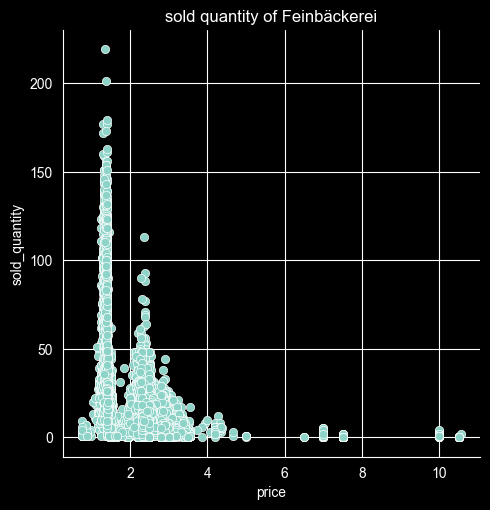

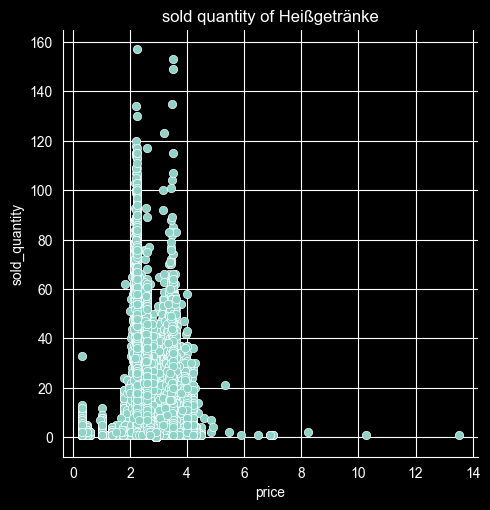

In [195]:
df_red = df[df['price'] > 0]
for category in top10_categories[:5]:
    sns.relplot(x = 'price', y = 'sold_quantity', data = df_red[df_red['category_name']==category],
                kind = 'scatter')
    plt.title('sold quantity of ' + category)


<Figure size 1200x800 with 0 Axes>

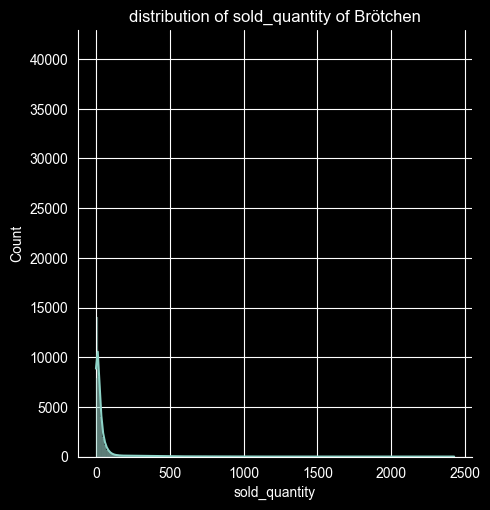

<Figure size 1200x800 with 0 Axes>

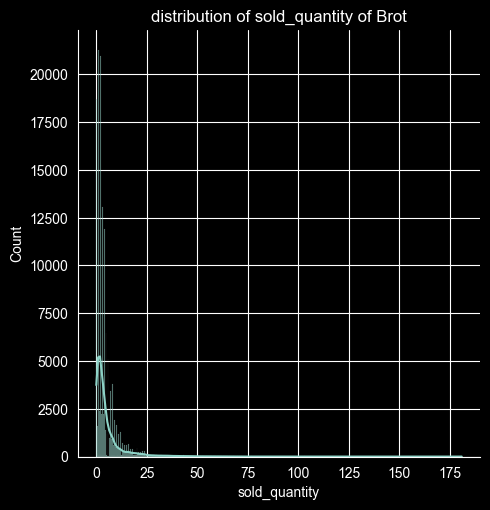

<Figure size 1200x800 with 0 Axes>

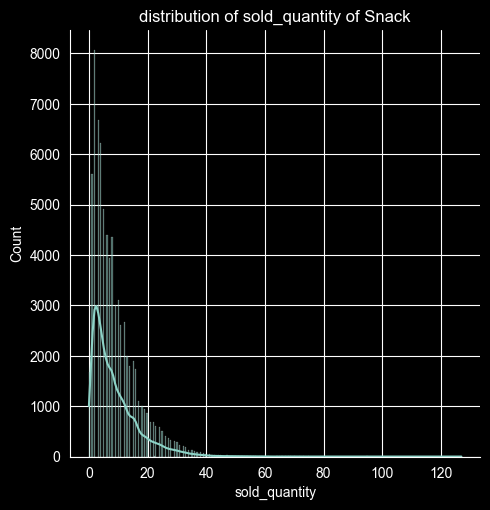

<Figure size 1200x800 with 0 Axes>

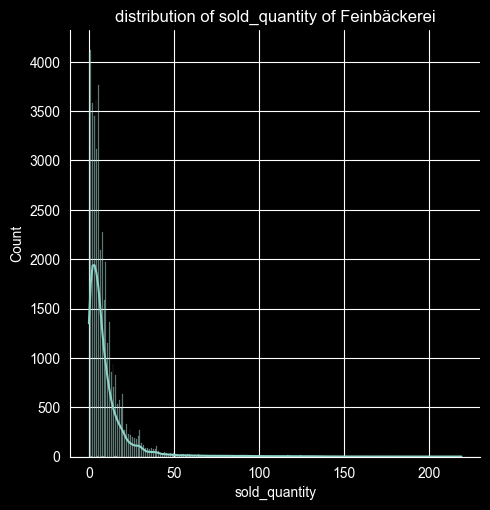

<Figure size 1200x800 with 0 Axes>

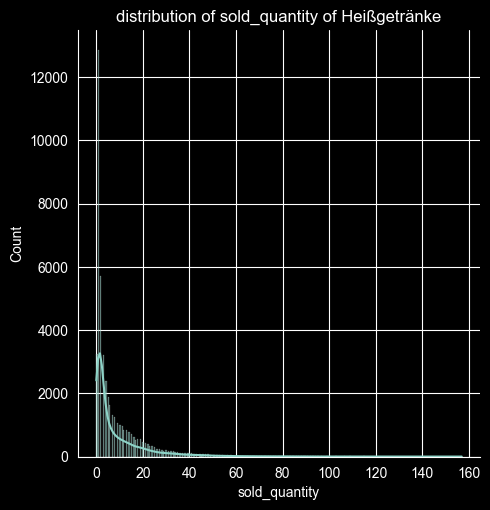

In [166]:
categories = top10_categories[:5]
categories = categories.astype('str')
for category in categories:
    picture_name = category + '_quant_hist.png'
    plt.figure(figsize=(12, 8))
    sns.displot(df[df['category_name'] == category]['sold_quantity'], kde=True)
    plt.title('distribution of sold_quantity of '+category)


<Axes: xlabel='sold_quantity', ylabel='Count'>

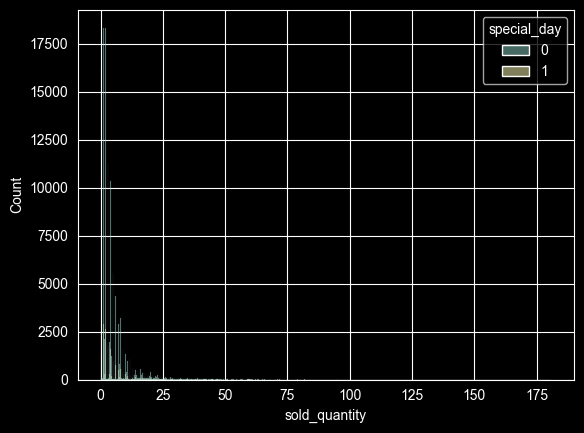

In [198]:
sns.histplot(x='sold_quantity', hue='special_day', data = df[df['category_name'] == 'Brot'])

<Axes: xlabel='category_name', ylabel='sold_quantity'>

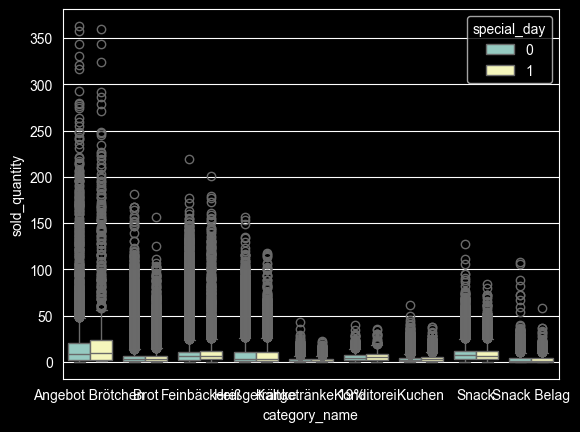

In [200]:
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(top10_categories_wo)], hue='special_day')

<Axes: xlabel='category_name', ylabel='sold_quantity'>

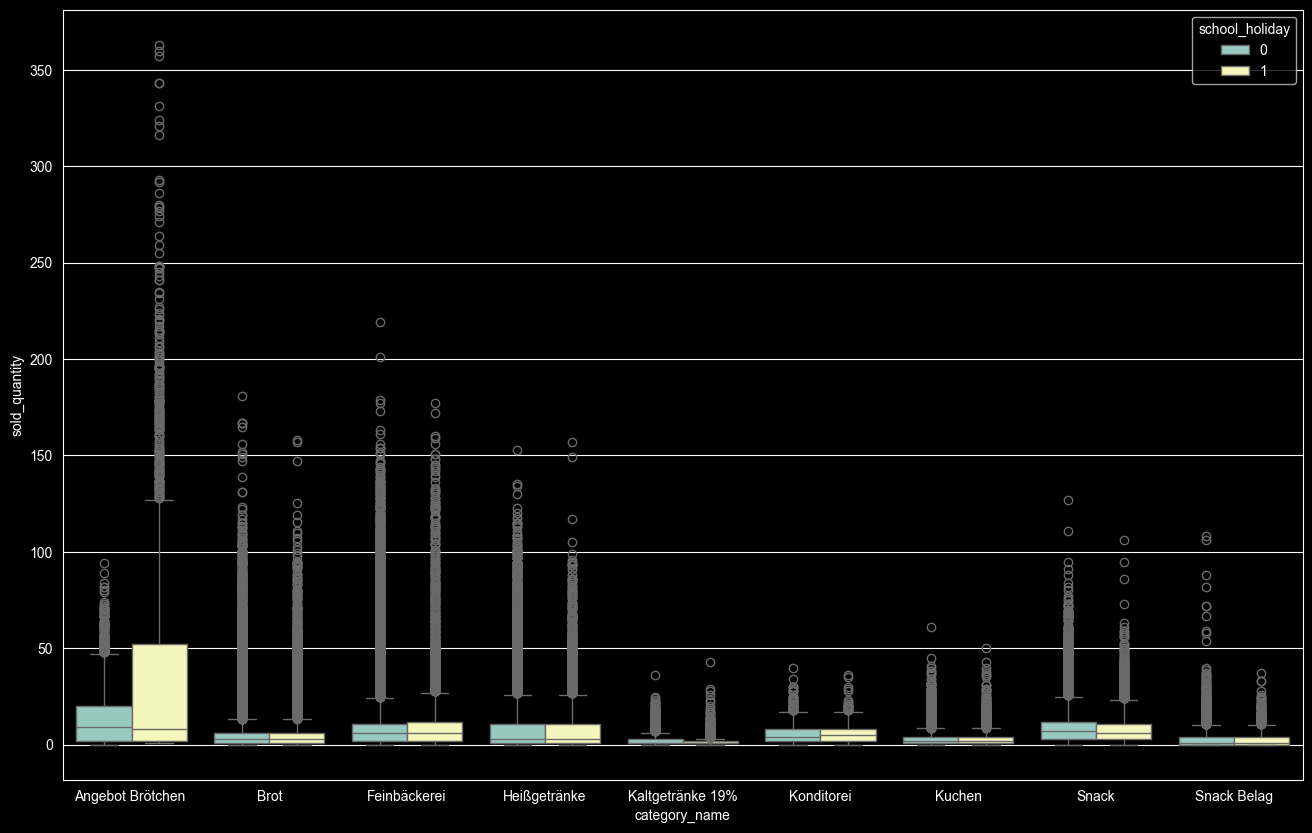

In [205]:
plt.figure(figsize=(16,10))
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(top10_categories_wo)], hue='school_holiday')

<Axes: xlabel='category_name', ylabel='sold_quantity'>

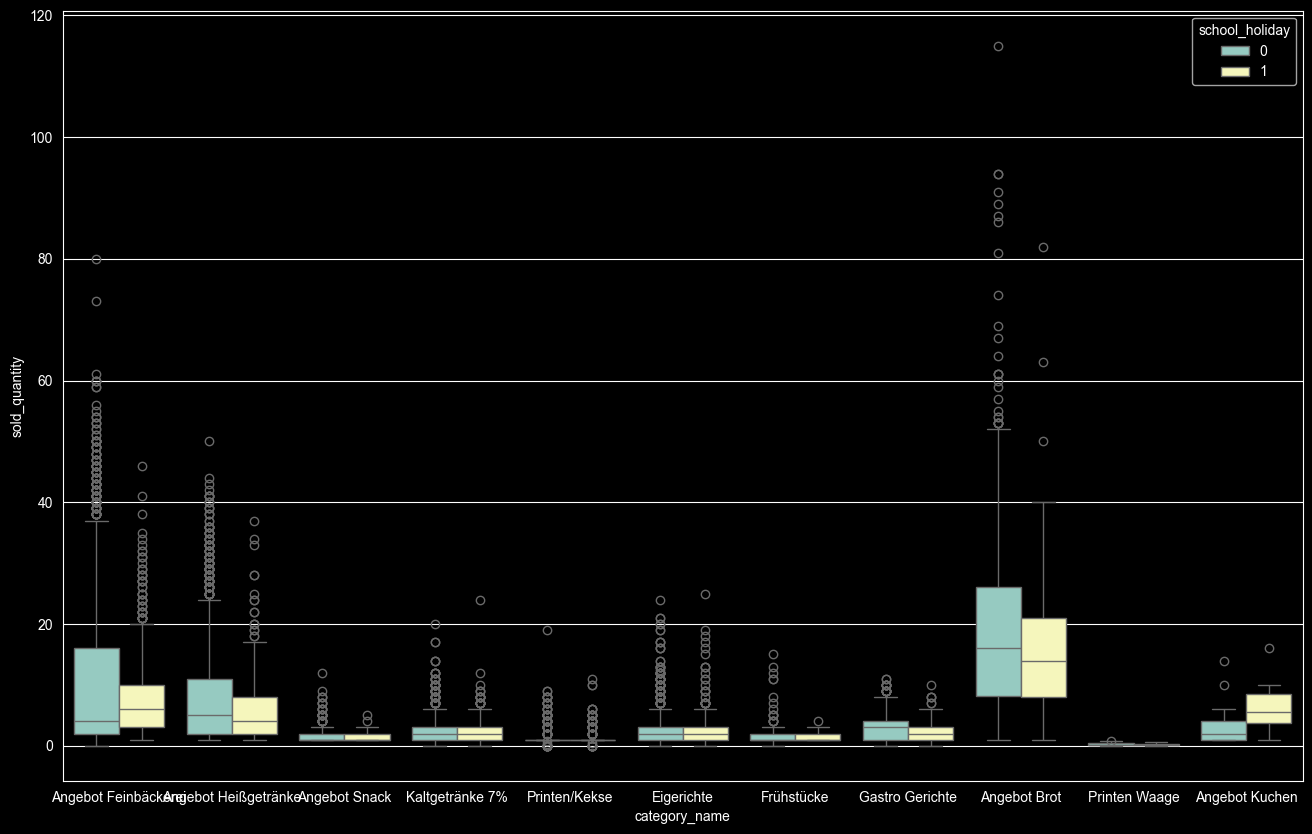

In [207]:
plt.figure(figsize=(16,10))
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(other_categories)], hue='school_holiday')

<Axes: xlabel='category_name', ylabel='sold_quantity'>

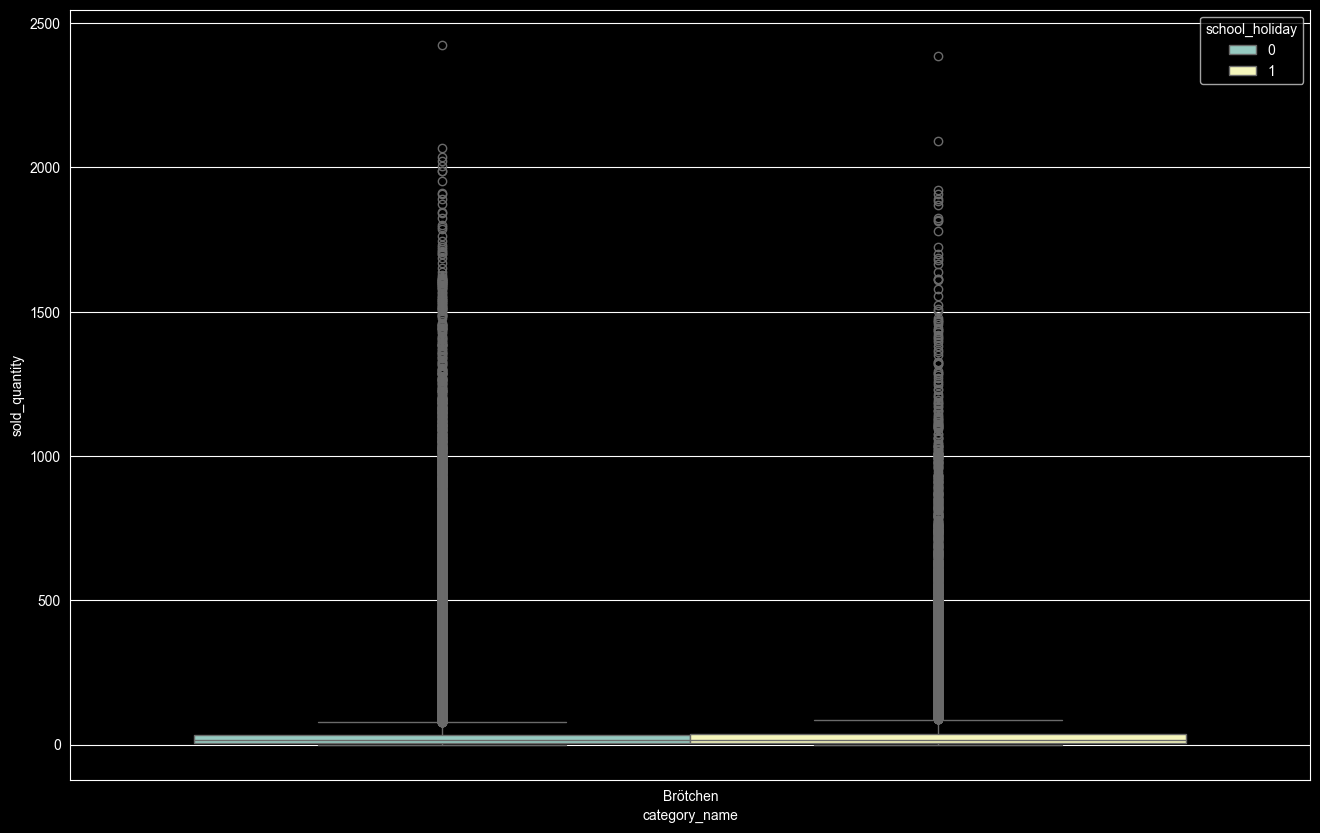

In [208]:
plt.figure(figsize=(16,10))
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name']=='Brötchen'], hue='school_holiday')

<Axes: xlabel='category_name', ylabel='sold_quantity'>

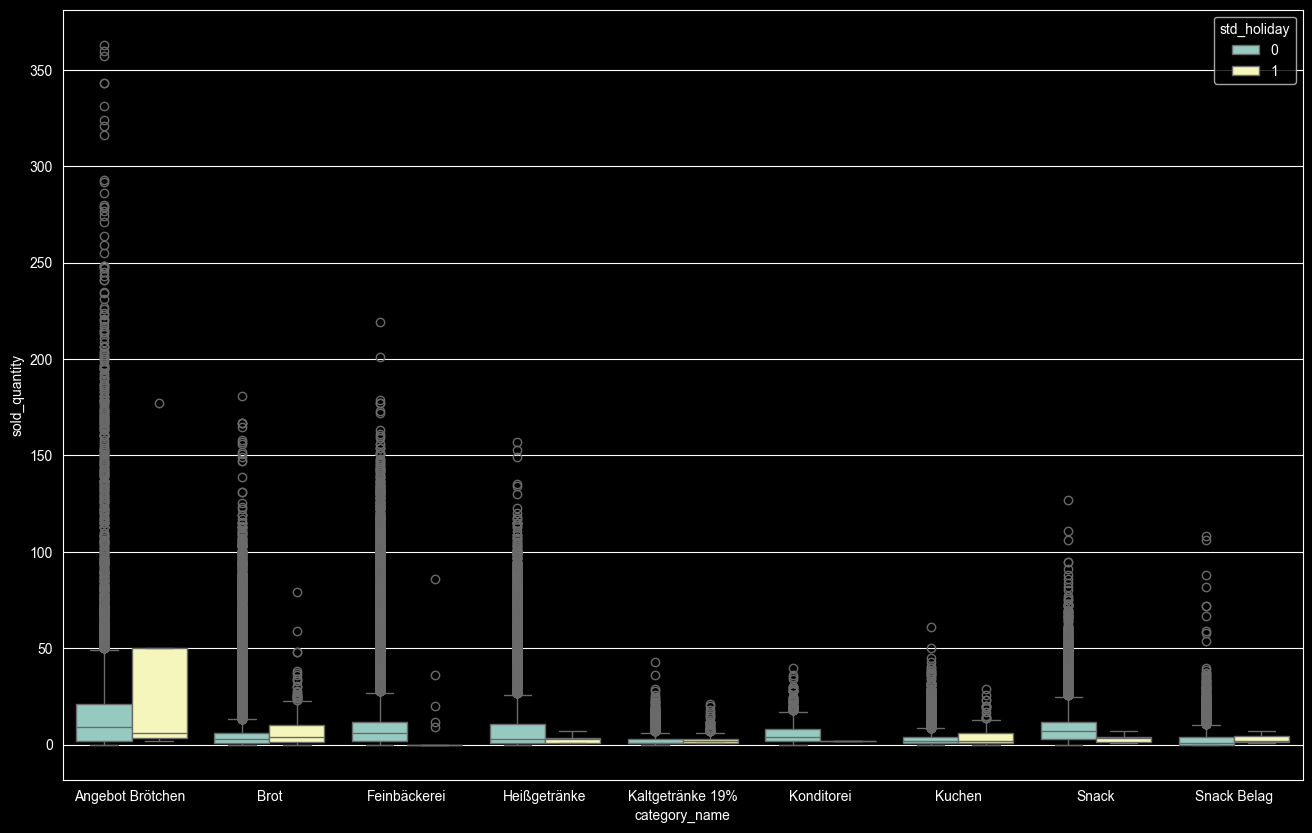

In [206]:
plt.figure(figsize=(16,10))
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(top10_categories_wo)], hue='std_holiday')

<Axes: xlabel='category_name', ylabel='sold_quantity'>

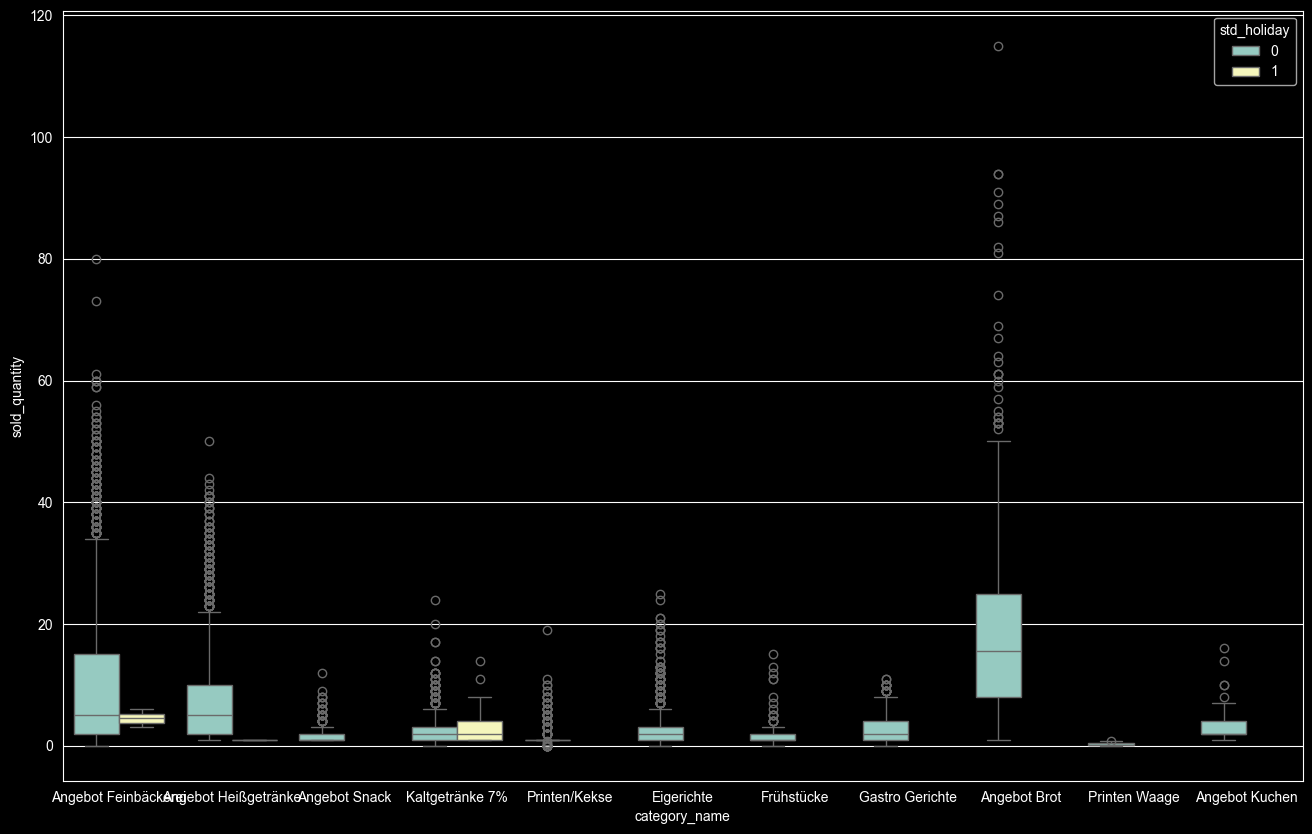

In [218]:
plt.figure(figsize=(16,10))
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = df[df['category_name'].isin(other_categories)], hue='std_holiday')

In [211]:
df.info()

<class 'pandas.DataFrame'>
Index: 696644 entries, 0 to 696645
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date                       696644 non-null  datetime64[ns]
 1   category_name              696644 non-null  object        
 2   item_id                    696644 non-null  int64         
 3   sold_quantity              696644 non-null  float64       
 4   price                      696644 non-null  float64       
 5   store_id                   696644 non-null  int64         
 6   month                      696644 non-null  int32         
 7   weekday                    696644 non-null  int32         
 8   zipcode                    696644 non-null  object        
 9   average_weekly_revenue_Q1  696644 non-null  float64       
 10  temperature                696644 non-null  float64       
 11  wind_speed                 696644 non-null  float64       
 12  wind